# Data Preprocessing and Feature Engineering

This notebook prepares the obesity-risk dataset for machine-learning model development.

## Objectives

- Load the raw dataset without modifying it
- Separate predictive features from the target
- Remove non-predictive identifiers
- Create stratified training, validation, and test datasets
- Define numerical, ordinal, and nominal feature groups
- Build reusable preprocessing pipelines
- Prevent data leakage

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "obesity.csv"
)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: c:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System
Dataset path: c:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\data\raw\obesity.csv
Dataset exists: True


In [3]:
project_root_string = str(PROJECT_ROOT)

if project_root_string not in sys.path:
    sys.path.insert(0, project_root_string)

print("Project root added to Python path")

Project root added to Python path


In [4]:
print("src folder exists:", (PROJECT_ROOT / "src").exists())

print(
    "__init__.py exists:",
    (PROJECT_ROOT / "src" / "__init__.py").exists(),
)

print(
    "preprocessing.py exists:",
    (PROJECT_ROOT / "src" / "preprocessing.py").exists(),
)

src folder exists: True
__init__.py exists: True
preprocessing.py exists: True


In [5]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

Dataset loaded successfully
Dataset shape: (20758, 18)


In [6]:
df.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [7]:
print("Columns:", df.columns.tolist())

Columns: ['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


In [8]:
identifier_column = "id"
target_column = "NObeyesdad"

print("Identifier column:", identifier_column)
print("Target column:", target_column)

Identifier column: id
Target column: NObeyesdad


In [9]:
X = df.drop(
    columns=[
        identifier_column,
        target_column,
    ]
)

y = df[target_column].copy()

In [10]:
print("Original dataset shape:", df.shape)
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Original dataset shape: (20758, 18)
Feature matrix shape: (20758, 16)
Target vector shape: (20758,)


In [11]:
print("Predictive features:")

for number, column in enumerate(X.columns, start=1):
    print(f"{number}. {column}")

Predictive features:
1. Gender
2. Age
3. Height
4. Weight
5. family_history_with_overweight
6. FAVC
7. FCVC
8. NCP
9. CAEC
10. SMOKE
11. CH2O
12. SCC
13. FAF
14. TUE
15. CALC
16. MTRANS


In [12]:
print(
    "Identifier present in X:",
    identifier_column in X.columns,
)

print(
    "Target present in X:",
    target_column in X.columns,
)

Identifier present in X: False
Target present in X: False


In [13]:
print("Number of target classes:", y.nunique())
print("Target classes:")

for class_name in sorted(y.unique()):
    print(class_name)

Number of target classes: 7
Target classes:
Insufficient_Weight
Normal_Weight
Obesity_Type_I
Obesity_Type_II
Obesity_Type_III
Overweight_Level_I
Overweight_Level_II


In [14]:
print("X row count:", len(X))
print("y row count:", len(y))
print("Indexes match:", X.index.equals(y.index))

X row count: 20758
y row count: 20758
Indexes match: True


In [15]:
numerical_features = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE",
]

In [16]:
ordinal_features = [
    "CAEC",
    "CALC",
]

In [17]:
nominal_features = [
    "Gender",
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC",
    "MTRANS",
]

In [18]:
print("Numerical features:")
print(numerical_features)

print("\nOrdinal categorical features:")
print(ordinal_features)

print("\nNominal categorical features:")
print(nominal_features)

print("\nFeature counts")
print("Numerical:", len(numerical_features))
print("Ordinal:", len(ordinal_features))
print("Nominal:", len(nominal_features))

Numerical features:
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

Ordinal categorical features:
['CAEC', 'CALC']

Nominal categorical features:
['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']

Feature counts
Numerical: 8
Ordinal: 2
Nominal: 6


In [19]:
grouped_features = (
    numerical_features
    + ordinal_features
    + nominal_features
)

missing_features = set(X.columns) - set(grouped_features)
unexpected_features = set(grouped_features) - set(X.columns)

print("Total grouped features:", len(grouped_features))
print("Missing features:", missing_features)
print("Unexpected features:", unexpected_features)

Total grouped features: 16
Missing features: set()
Unexpected features: set()


In [20]:
feature_group_sets = {
    "numerical": set(numerical_features),
    "ordinal": set(ordinal_features),
    "nominal": set(nominal_features),
}

numerical_ordinal_overlap = (
    feature_group_sets["numerical"]
    & feature_group_sets["ordinal"]
)

numerical_nominal_overlap = (
    feature_group_sets["numerical"]
    & feature_group_sets["nominal"]
)

ordinal_nominal_overlap = (
    feature_group_sets["ordinal"]
    & feature_group_sets["nominal"]
)

print(
    "Numerical and ordinal overlap:",
    numerical_ordinal_overlap,
)

print(
    "Numerical and nominal overlap:",
    numerical_nominal_overlap,
)

print(
    "Ordinal and nominal overlap:",
    ordinal_nominal_overlap,
)

Numerical and ordinal overlap: set()
Numerical and nominal overlap: set()
Ordinal and nominal overlap: set()


In [21]:
assert len(grouped_features) == len(set(grouped_features)), (
    "A feature appears in more than one group."
)

assert set(grouped_features) == set(X.columns), (
    "Feature groups do not match the predictive columns."
)

print("Feature group validation passed")

Feature group validation passed


In [22]:
RANDOM_STATE = 42
TRAIN_SIZE = 0.70
TEMPORARY_SIZE = 0.30

print("Total split proportion:", TRAIN_SIZE + TEMPORARY_SIZE)

Total split proportion: 1.0


In [23]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    train_size=TRAIN_SIZE,
    test_size=TEMPORARY_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [24]:
print("Full feature set:", X.shape)
print("Full target set:", y.shape)

print("\nTraining features:", X_train.shape)
print("Training target:", y_train.shape)

print("\nTemporary features:", X_temp.shape)
print("Temporary target:", y_temp.shape)

Full feature set: (20758, 16)
Full target set: (20758,)

Training features: (14530, 16)
Training target: (14530,)

Temporary features: (6228, 16)
Temporary target: (6228,)


In [25]:
training_percentage = len(X_train) / len(X) * 100
temporary_percentage = len(X_temp) / len(X) * 100

print(f"Training percentage: {training_percentage:.2f}%")
print(f"Temporary percentage: {temporary_percentage:.2f}%")

Training percentage: 70.00%
Temporary percentage: 30.00%


In [26]:
print(
    "Training indexes match:",
    X_train.index.equals(y_train.index),
)

print(
    "Temporary indexes match:",
    X_temp.index.equals(y_temp.index),
)

Training indexes match: True
Temporary indexes match: True


In [27]:
overlapping_indexes = (
    set(X_train.index)
    & set(X_temp.index)
)

print(
    "Number of overlapping records:",
    len(overlapping_indexes),
)

Number of overlapping records: 0


In [28]:
assert len(X_train) == len(y_train), (
    "Training features and targets have different lengths"
)

assert len(X_temp) == len(y_temp), (
    "Temporary features and targets have different lengths"
)

assert len(X_train) + len(X_temp) == len(X), (
    "The split does not contain every original record"
)

assert not overlapping_indexes, (
    "Training and temporary sets contain overlapping records"
)

print("Initial split validation passed")

Initial split validation passed


In [29]:
VALIDATION_SHARE_OF_TEMP = 0.50
TEST_SHARE_OF_TEMP = 0.50

print(
    "Temporary split total:",
    VALIDATION_SHARE_OF_TEMP + TEST_SHARE_OF_TEMP,
)

Temporary split total: 1.0


In [30]:
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=TEST_SHARE_OF_TEMP,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

In [31]:
print("Training features:", X_train.shape)
print("Training target:", y_train.shape)

print("\nValidation features:", X_validation.shape)
print("Validation target:", y_validation.shape)

print("\nTest features:", X_test.shape)
print("Test target:", y_test.shape)

Training features: (14530, 16)
Training target: (14530,)

Validation features: (3114, 16)
Validation target: (3114,)

Test features: (3114, 16)
Test target: (3114,)


In [32]:
split_percentages = pd.Series(
    {
        "Training": len(X_train) / len(X) * 100,
        "Validation": len(X_validation) / len(X) * 100,
        "Test": len(X_test) / len(X) * 100,
    },
    name="Percentage",
).round(2)

split_percentages

Training      70.0
Validation    15.0
Test          15.0
Name: Percentage, dtype: float64

In [33]:
alignment_checks = {
    "Training": X_train.index.equals(y_train.index),
    "Validation": X_validation.index.equals(y_validation.index),
    "Test": X_test.index.equals(y_test.index),
}

alignment_checks

{'Training': True, 'Validation': True, 'Test': True}

In [34]:
train_validation_overlap = (
    set(X_train.index)
    & set(X_validation.index)
)

train_test_overlap = (
    set(X_train.index)
    & set(X_test.index)
)

validation_test_overlap = (
    set(X_validation.index)
    & set(X_test.index)
)

print(
    "Training-validation overlap:",
    len(train_validation_overlap),
)

print(
    "Training-test overlap:",
    len(train_test_overlap),
)

print(
    "Validation-test overlap:",
    len(validation_test_overlap),
)

Training-validation overlap: 0
Training-test overlap: 0
Validation-test overlap: 0


In [35]:
total_split_records = (
    len(X_train)
    + len(X_validation)
    + len(X_test)
)

print("Original records:", len(X))
print("Records after splitting:", total_split_records)
print("All records retained:", total_split_records == len(X))

Original records: 20758
Records after splitting: 20758
All records retained: True


In [36]:
assert len(X_validation) == len(y_validation), (
    "Validation features and targets have different lengths"
)

assert len(X_test) == len(y_test), (
    "Test features and targets have different lengths"
)

assert total_split_records == len(X), (
    "Some records were lost or duplicated during splitting"
)

assert not train_validation_overlap, (
    "Training and validation sets overlap"
)

assert not train_test_overlap, (
    "Training and test sets overlap"
)

assert not validation_test_overlap, (
    "Validation and test sets overlap"
)

assert all(alignment_checks.values()), (
    "Features and targets are not correctly aligned"
)

print("Final dataset split validation passed")

Final dataset split validation passed


In [37]:
class_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

In [38]:
def calculate_class_percentages(target_series):
    return (
        target_series
        .value_counts(normalize=True)
        .mul(100)
        .reindex(class_order)
        .round(2)
    )

In [39]:
full_distribution = calculate_class_percentages(y)
training_distribution = calculate_class_percentages(y_train)
validation_distribution = calculate_class_percentages(y_validation)
test_distribution = calculate_class_percentages(y_test)

In [40]:
class_distribution_comparison = pd.DataFrame({
    "Full Dataset (%)": full_distribution,
    "Training (%)": training_distribution,
    "Validation (%)": validation_distribution,
    "Test (%)": test_distribution,
})

class_distribution_comparison

,Full Dataset (%),Training (%),Validation (%),Test (%)
NObeyesdad,,,,
Insufficient_Weight,12.15,12.15,12.17,12.14
Normal_Weight,14.85,14.85,14.87,14.84
Overweight_Level_I,11.69,11.69,11.69,11.69
Overweight_Level_II,12.15,12.15,12.14,12.17
Obesity_Type_I,14.02,14.02,14.00,14.03
Obesity_Type_II,15.65,15.65,15.64,15.64
Obesity_Type_III,19.49,19.49,19.49,19.49


In [41]:
distribution_differences = pd.DataFrame({
    "Training difference": (
        training_distribution - full_distribution
    ).abs(),

    "Validation difference": (
        validation_distribution - full_distribution
    ).abs(),

    "Test difference": (
        test_distribution - full_distribution
    ).abs(),
}).round(2)

distribution_differences

,Training difference,Validation difference,Test difference
NObeyesdad,,,
Insufficient_Weight,0.0,0.02,0.01
Normal_Weight,0.0,0.02,0.01
Overweight_Level_I,0.0,0.00,0.00
Overweight_Level_II,0.0,0.01,0.02
Obesity_Type_I,0.0,0.02,0.01
Obesity_Type_II,0.0,0.01,0.01
Obesity_Type_III,0.0,0.00,0.00


In [42]:
maximum_distribution_difference = (
    distribution_differences
    .to_numpy()
    .max()
)

print(
    "Maximum class percentage difference:",
    f"{maximum_distribution_difference:.2f} percentage points",
)

Maximum class percentage difference: 0.02 percentage points


In [43]:
MAX_ALLOWED_DIFFERENCE = 0.20

assert maximum_distribution_difference <= MAX_ALLOWED_DIFFERENCE, (
    "The class proportions differ more than the accepted tolerance."
)

print("Class distribution validation passed")

Class distribution validation passed


In [44]:
distribution_chart_data = (
    class_distribution_comparison
    .reset_index()
)

distribution_chart_data = distribution_chart_data.rename(
    columns={
        distribution_chart_data.columns[0]: "Obesity Class"
    }
)

distribution_chart_data

,Obesity Class,Full Dataset (%),Training (%),Validation (%),Test (%)
0,Insufficient_Weight,12.15,12.15,12.17,12.14
1,Normal_Weight,14.85,14.85,14.87,14.84
2,Overweight_Level_I,11.69,11.69,11.69,11.69
3,Overweight_Level_II,12.15,12.15,12.14,12.17
4,Obesity_Type_I,14.02,14.02,14.00,14.03
5,Obesity_Type_II,15.65,15.65,15.64,15.64
6,Obesity_Type_III,19.49,19.49,19.49,19.49


In [45]:
distribution_chart_long = distribution_chart_data.melt(
    id_vars="Obesity Class",
    var_name="Dataset Split",
    value_name="Percentage",
)

distribution_chart_long.head()

,Obesity Class,Dataset Split,Percentage
0,Insufficient_Weight,Full Dataset (%),12.15
1,Normal_Weight,Full Dataset (%),14.85
2,Overweight_Level_I,Full Dataset (%),11.69
3,Overweight_Level_II,Full Dataset (%),12.15
4,Obesity_Type_I,Full Dataset (%),14.02


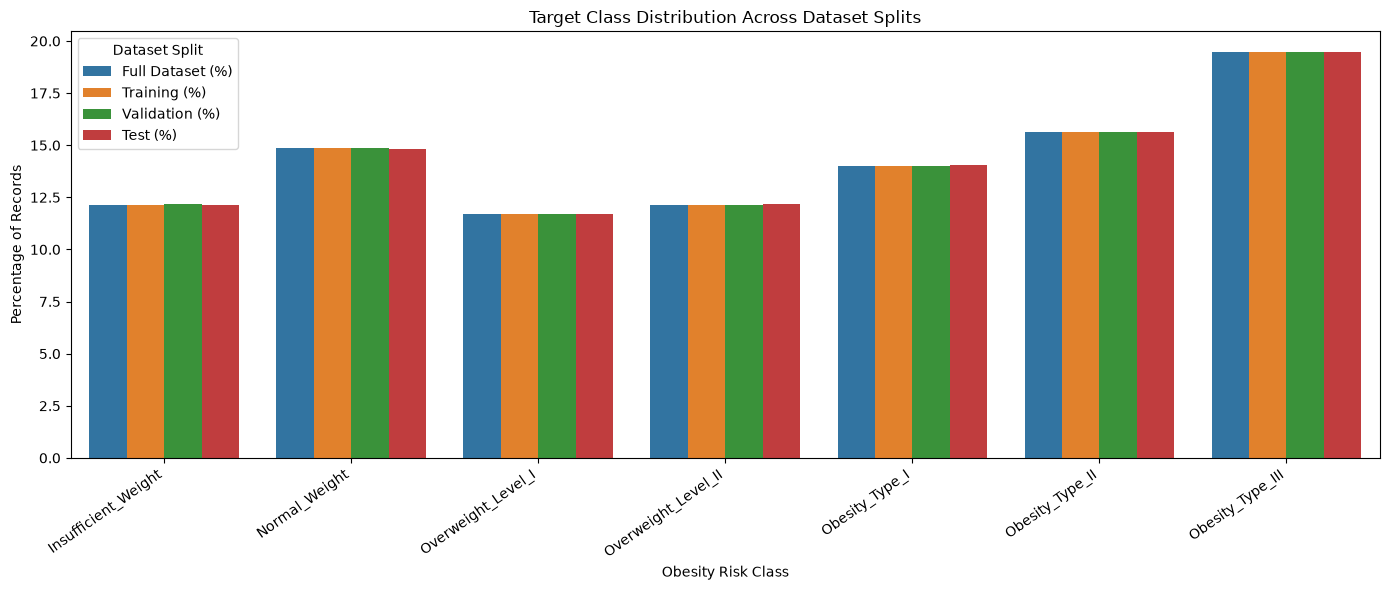

In [46]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=distribution_chart_long,
    x="Obesity Class",
    y="Percentage",
    hue="Dataset Split",
)

plt.title("Target Class Distribution Across Dataset Splits")
plt.xlabel("Obesity Risk Class")
plt.ylabel("Percentage of Records")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Dataset Split")
plt.tight_layout()
plt.show()

In [47]:
for column in ordinal_features:
    observed_values = sorted(
        X_train[column]
        .dropna()
        .unique()
        .tolist()
    )

    print(f"{column}: {observed_values}")

CAEC: ['Always', 'Frequently', 'Sometimes', 'no']
CALC: ['Frequently', 'Sometimes', 'no']


In [48]:
caec_order = [
    "no",
    "Sometimes",
    "Frequently",
    "Always",
]

calc_order = [
    "no",
    "Sometimes",
    "Frequently",
]

In [49]:
ordinal_category_orders = {
    "CAEC": caec_order,
    "CALC": calc_order,
}

ordinal_category_orders

{'CAEC': ['no', 'Sometimes', 'Frequently', 'Always'],
 'CALC': ['no', 'Sometimes', 'Frequently']}

In [50]:
configured_ordinal_features = set(
    ordinal_category_orders.keys()
)

expected_ordinal_features = set(
    ordinal_features
)

print(
    "Missing ordinal configurations:",
    expected_ordinal_features
    - configured_ordinal_features,
)

print(
    "Unexpected ordinal configurations:",
    configured_ordinal_features
    - expected_ordinal_features,
)

Missing ordinal configurations: set()
Unexpected ordinal configurations: set()


In [51]:
ordinal_validation_results = []

for column, expected_order in ordinal_category_orders.items():
    observed_values = set(
        X_train[column]
        .dropna()
        .unique()
    )

    configured_values = set(expected_order)

    unexpected_values = (
        observed_values
        - configured_values
    )

    configured_but_missing = (
        configured_values
        - observed_values
    )

    ordinal_validation_results.append({
        "Feature": column,
        "Observed values": sorted(observed_values),
        "Unexpected values": sorted(unexpected_values),
        "Configured but missing": sorted(configured_but_missing),
    })

ordinal_validation_df = pd.DataFrame(
    ordinal_validation_results
)

ordinal_validation_df

,Feature,Observed values,Unexpected values,Configured but missing
0,CAEC,"[Always, Frequently, Sometimes, no]",[],[]
1,CALC,"[Frequently, Sometimes, no]",[],[]


In [52]:
def find_unseen_categories(
    training_data,
    comparison_data,
    columns,
):
    results = {}

    for column in columns:
        training_values = set(
            training_data[column]
            .dropna()
            .unique()
        )

        comparison_values = set(
            comparison_data[column]
            .dropna()
            .unique()
        )

        results[column] = sorted(
            comparison_values
            - training_values
        )

    return results

In [53]:
validation_unseen_categories = find_unseen_categories(
    X_train,
    X_validation,
    ordinal_features,
)

test_unseen_categories = find_unseen_categories(
    X_train,
    X_test,
    ordinal_features,
)

print(
    "Unseen validation categories:",
    validation_unseen_categories,
)

print(
    "Unseen test categories:",
    test_unseen_categories,
)

Unseen validation categories: {'CAEC': [], 'CALC': []}
Unseen test categories: {'CAEC': [], 'CALC': []}


In [54]:
assert (
    configured_ordinal_features
    == expected_ordinal_features
), "Ordinal feature configuration is incomplete"

for result in ordinal_validation_results:
    assert not result["Unexpected values"], (
        f"Unexpected category found in "
        f"{result['Feature']}"
    )

assert all(
    not values
    for values
    in validation_unseen_categories.values()
), "Validation data contains unseen ordinal categories"

assert all(
    not values
    for values
    in test_unseen_categories.values()
), "Test data contains unseen ordinal categories"

print("Ordinal category validation passed")

Ordinal category validation passed


In [55]:
ordinal_categories = [
    ordinal_category_orders[column]
    for column in ordinal_features
]

ordinal_categories

[['no', 'Sometimes', 'Frequently', 'Always'],
 ['no', 'Sometimes', 'Frequently']]

In [56]:
numerical_missing_values = (
    X_train[numerical_features]
    .isna()
    .sum()
)

numerical_missing_values

Age       0
Height    0
Weight    0
FCVC      0
NCP       0
CH2O      0
FAF       0
TUE       0
dtype: int64

In [57]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

numerical_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [58]:
X_train_numerical_transformed = (
    numerical_pipeline.fit_transform(
        X_train[numerical_features]
    )
)

In [59]:
X_validation_numerical_transformed = (
    numerical_pipeline.transform(
        X_validation[numerical_features]
    )
)

X_test_numerical_transformed = (
    numerical_pipeline.transform(
        X_test[numerical_features]
    )
)

In [60]:
print(
    "Training numerical shape:",
    X_train_numerical_transformed.shape,
)

print(
    "Validation numerical shape:",
    X_validation_numerical_transformed.shape,
)

print(
    "Test numerical shape:",
    X_test_numerical_transformed.shape,
)

Training numerical shape: (14530, 8)
Validation numerical shape: (3114, 8)
Test numerical shape: (3114, 8)


In [61]:
learned_medians = pd.Series(
    numerical_pipeline
    .named_steps["imputer"]
    .statistics_,
    index=numerical_features,
    name="Training Median",
)

learned_medians

Age       22.771612
Height     1.700000
Weight    84.000000
FCVC       2.407817
NCP        3.000000
CH2O       2.000000
FAF        1.000000
TUE        0.574016
Name: Training Median, dtype: float64

In [62]:
scaled_training_df = pd.DataFrame(
    X_train_numerical_transformed,
    columns=numerical_features,
    index=X_train.index,
)

scaled_training_df.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
7219,0.385914,-0.881557,0.910609,1.038204,0.343418,1.236961,-1.167175,-0.820903
10037,0.373562,0.180375,0.948677,1.038204,0.343418,1.161405,-1.122673,-0.771579
9426,1.408144,0.638226,1.215992,0.976776,0.343418,0.645981,-0.024391,-1.026618
19859,0.213334,0.889680,1.006426,-2.514706,0.343418,-0.042607,-0.764289,-1.011249
1368,0.031084,-0.799056,-0.146914,1.038204,-2.476780,1.592657,0.029060,-1.026618


In [63]:
scaling_summary = pd.DataFrame({
    "Mean": scaled_training_df.mean(),
    "Standard Deviation": scaled_training_df.std(
        ddof=0
    ),
}).round(4)

scaling_summary

,Mean,Standard Deviation
Age,0.0,1.0
Height,-0.0,1.0
Weight,0.0,1.0
FCVC,-0.0,1.0
NCP,-0.0,1.0
CH2O,-0.0,1.0
FAF,0.0,1.0
TUE,0.0,1.0


In [64]:
transformed_numerical_sets = {
    "Training": X_train_numerical_transformed,
    "Validation": X_validation_numerical_transformed,
    "Test": X_test_numerical_transformed,
}

for dataset_name, transformed_data in (
    transformed_numerical_sets.items()
):
    missing_count = pd.isna(
        transformed_data
    ).sum()

    infinite_count = (
        ~np.isfinite(transformed_data)
    ).sum()

    print(
        f"{dataset_name} missing values:",
        missing_count,
    )

    print(
        f"{dataset_name} infinite values:",
        infinite_count,
    )

Training missing values: 0
Training infinite values: 0
Validation missing values: 0
Validation infinite values: 0
Test missing values: 0
Test infinite values: 0


In [65]:
assert X_train_numerical_transformed.shape == (
    len(X_train),
    len(numerical_features),
), "Training numerical output has an incorrect shape"

assert X_validation_numerical_transformed.shape == (
    len(X_validation),
    len(numerical_features),
), "Validation numerical output has an incorrect shape"

assert X_test_numerical_transformed.shape == (
    len(X_test),
    len(numerical_features),
), "Test numerical output has an incorrect shape"

for dataset_name, transformed_data in (
    transformed_numerical_sets.items()
):
    assert np.isfinite(transformed_data).all(), (
        f"{dataset_name} numerical output "
        "contains missing or infinite values"
    )

assert np.allclose(
    scaled_training_df.mean().to_numpy(),
    0,
    atol=1e-10,
), "Scaled training means are not close to zero"

assert np.allclose(
    scaled_training_df
    .std(ddof=0)
    .to_numpy(),
    1,
    atol=1e-10,
), "Scaled training standard deviations are not close to one"

print("Numerical preprocessing validation passed")

Numerical preprocessing validation passed


In [66]:
categorical_features = (
    ordinal_features
    + nominal_features
)

categorical_missing_values = (
    X_train[categorical_features]
    .isna()
    .sum()
)

categorical_missing_values

CAEC                              0
CALC                              0
Gender                            0
family_history_with_overweight    0
FAVC                              0
SMOKE                             0
SCC                               0
MTRANS                            0
dtype: int64

In [67]:
ordinal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OrdinalEncoder(
                categories=ordinal_categories,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)

ordinal_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto ac

In [68]:
X_train_ordinal_transformed = (
    ordinal_pipeline.fit_transform(
        X_train[ordinal_features]
    )
)

X_validation_ordinal_transformed = (
    ordinal_pipeline.transform(
        X_validation[ordinal_features]
    )
)

X_test_ordinal_transformed = (
    ordinal_pipeline.transform(
        X_test[ordinal_features]
    )
)

In [69]:
ordinal_training_df = pd.DataFrame(
    X_train_ordinal_transformed,
    columns=ordinal_features,
    index=X_train.index,
)

ordinal_training_df.head()

,CAEC,CALC
7219,1.0,1.0
10037,1.0,1.0
9426,1.0,1.0
19859,1.0,1.0
1368,1.0,1.0


In [70]:
for column in ordinal_features:
    print(
        column,
        sorted(
            ordinal_training_df[column]
            .unique()
            .tolist()
        ),
    )

CAEC [0.0, 1.0, 2.0, 3.0]
CALC [0.0, 1.0, 2.0]


In [71]:
nominal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

nominal_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto ac

In [72]:
X_train_nominal_transformed = (
    nominal_pipeline.fit_transform(
        X_train[nominal_features]
    )
)

X_validation_nominal_transformed = (
    nominal_pipeline.transform(
        X_validation[nominal_features]
    )
)

X_test_nominal_transformed = (
    nominal_pipeline.transform(
        X_test[nominal_features]
    )
)

In [73]:
nominal_feature_names = (
    nominal_pipeline
    .named_steps["encoder"]
    .get_feature_names_out(nominal_features)
)

print("Original nominal features:", len(nominal_features))
print("Encoded nominal features:", len(nominal_feature_names))

nominal_feature_names

Original nominal features: 6
Encoded nominal features: 15


array(['Gender_Female', 'Gender_Male',
       'family_history_with_overweight_no',
       'family_history_with_overweight_yes', 'FAVC_no', 'FAVC_yes',
       'SMOKE_no', 'SMOKE_yes', 'SCC_no', 'SCC_yes', 'MTRANS_Automobile',
       'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation',
       'MTRANS_Walking'], dtype=object)

In [74]:
nominal_training_df = pd.DataFrame(
    X_train_nominal_transformed,
    columns=nominal_feature_names,
    index=X_train.index,
)

nominal_training_df.head()

,Gender_Female,Gender_Male,family_history_with_overweight_no,family_history_with_overweight_yes,FAVC_no,FAVC_yes,SMOKE_no,SMOKE_yes,SCC_no,SCC_yes,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
7219,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
10037,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9426,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
19859,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1368,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [75]:
nominal_unique_values = np.unique(
    X_train_nominal_transformed
)

print(
    "Unique nominal encoded values:",
    nominal_unique_values,
)

Unique nominal encoded values: [0. 1.]


In [76]:
print(
    "Ordinal training shape:",
    X_train_ordinal_transformed.shape,
)

print(
    "Ordinal validation shape:",
    X_validation_ordinal_transformed.shape,
)

print(
    "Ordinal test shape:",
    X_test_ordinal_transformed.shape,
)

print(
    "\nNominal training shape:",
    X_train_nominal_transformed.shape,
)

print(
    "Nominal validation shape:",
    X_validation_nominal_transformed.shape,
)

print(
    "Nominal test shape:",
    X_test_nominal_transformed.shape,
)

Ordinal training shape: (14530, 2)
Ordinal validation shape: (3114, 2)
Ordinal test shape: (3114, 2)

Nominal training shape: (14530, 15)
Nominal validation shape: (3114, 15)
Nominal test shape: (3114, 15)


In [77]:
assert X_train_ordinal_transformed.shape == (
    len(X_train),
    len(ordinal_features),
), "Ordinal training output has an incorrect shape"

assert X_validation_ordinal_transformed.shape == (
    len(X_validation),
    len(ordinal_features),
), "Ordinal validation output has an incorrect shape"

assert X_test_ordinal_transformed.shape == (
    len(X_test),
    len(ordinal_features),
), "Ordinal test output has an incorrect shape"

assert X_train_nominal_transformed.shape[0] == len(
    X_train
), "Nominal training row count is incorrect"

assert X_validation_nominal_transformed.shape[0] == len(
    X_validation
), "Nominal validation row count is incorrect"

assert X_test_nominal_transformed.shape[0] == len(
    X_test
), "Nominal test row count is incorrect"

assert X_train_nominal_transformed.shape[1] == len(
    nominal_feature_names
), "Nominal feature count does not match its names"

assert np.isfinite(
    X_train_ordinal_transformed
).all(), "Ordinal output contains invalid values"

assert np.isfinite(
    X_train_nominal_transformed
).all(), "Nominal output contains invalid values"

print("Categorical preprocessing validation passed")

Categorical preprocessing validation passed


In [78]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features,
        ),
        (
            "ordinal",
            ordinal_pipeline,
            ordinal_features,
        ),
        (
            "nominal",
            nominal_pipeline,
            nominal_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and `

In [79]:
print("Configured transformers:")

for (
    transformer_name,
    transformer_pipeline,
    transformer_columns,
) in preprocessor.transformers:
    print(
        f"{transformer_name}: "
        f"{len(transformer_columns)} columns"
    )
    print(transformer_columns)
    print()

Configured transformers:
numerical: 8 columns
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

ordinal: 2 columns
['CAEC', 'CALC']

nominal: 6 columns
['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']



In [80]:
preprocessor_columns = []

for (
    transformer_name,
    transformer_pipeline,
    transformer_columns,
) in preprocessor.transformers:
    preprocessor_columns.extend(
        transformer_columns
    )

print(
    "Number of configured columns:",
    len(preprocessor_columns),
)

print(
    "Configured columns:",
    preprocessor_columns,
)

Number of configured columns: 16
Configured columns: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'CAEC', 'CALC', 'Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']


In [81]:
missing_preprocessor_columns = (
    set(X_train.columns)
    - set(preprocessor_columns)
)

unexpected_preprocessor_columns = (
    set(preprocessor_columns)
    - set(X_train.columns)
)

print(
    "Missing preprocessing columns:",
    missing_preprocessor_columns,
)

print(
    "Unexpected preprocessing columns:",
    unexpected_preprocessor_columns,
)

Missing preprocessing columns: set()
Unexpected preprocessing columns: set()


In [82]:
duplicate_preprocessor_columns = {
    column
    for column in preprocessor_columns
    if preprocessor_columns.count(column) > 1
}

print(
    "Columns assigned more than once:",
    duplicate_preprocessor_columns,
)

Columns assigned more than once: set()


In [83]:
expected_preprocessor_columns = (
    numerical_features
    + ordinal_features
    + nominal_features
)

print(
    "Preprocessor matches feature groups:",
    set(preprocessor_columns)
    == set(expected_preprocessor_columns),
)

Preprocessor matches feature groups: True


In [84]:
assert len(preprocessor_columns) == len(
    X_train.columns
), "The preprocessor contains an incorrect number of columns"

assert not missing_preprocessor_columns, (
    "Some training columns do not have preprocessing rules"
)

assert not unexpected_preprocessor_columns, (
    "The preprocessor contains unknown columns"
)

assert not duplicate_preprocessor_columns, (
    "Some columns are assigned to multiple transformers"
)

assert set(preprocessor_columns) == set(
    expected_preprocessor_columns
), "The preprocessor does not match the feature groups"

print("Combined preprocessor configuration passed")

Combined preprocessor configuration passed


In [85]:
X_train_transformed = preprocessor.fit_transform(
    X_train
)

In [86]:
X_validation_transformed = preprocessor.transform(
    X_validation
)

X_test_transformed = preprocessor.transform(
    X_test
)

In [87]:
print(
    "Training output type:",
    type(X_train_transformed),
)

print(
    "Validation output type:",
    type(X_validation_transformed),
)

print(
    "Test output type:",
    type(X_test_transformed),
)

Training output type: <class 'numpy.ndarray'>
Validation output type: <class 'numpy.ndarray'>
Test output type: <class 'numpy.ndarray'>


In [88]:
print(
    "Training transformed shape:",
    X_train_transformed.shape,
)

print(
    "Validation transformed shape:",
    X_validation_transformed.shape,
)

print(
    "Test transformed shape:",
    X_test_transformed.shape,
)

Training transformed shape: (14530, 25)
Validation transformed shape: (3114, 25)
Test transformed shape: (3114, 25)


In [89]:
transformed_feature_names = (
    preprocessor.get_feature_names_out()
)

print(
    "Number of transformed features:",
    len(transformed_feature_names),
)

transformed_feature_names

Number of transformed features: 25


array(['numerical__Age', 'numerical__Height', 'numerical__Weight',
       'numerical__FCVC', 'numerical__NCP', 'numerical__CH2O',
       'numerical__FAF', 'numerical__TUE', 'ordinal__CAEC',
       'ordinal__CALC', 'nominal__Gender_Female', 'nominal__Gender_Male',
       'nominal__family_history_with_overweight_no',
       'nominal__family_history_with_overweight_yes', 'nominal__FAVC_no',
       'nominal__FAVC_yes', 'nominal__SMOKE_no', 'nominal__SMOKE_yes',
       'nominal__SCC_no', 'nominal__SCC_yes',
       'nominal__MTRANS_Automobile', 'nominal__MTRANS_Bike',
       'nominal__MTRANS_Motorbike',
       'nominal__MTRANS_Public_Transportation', 'nominal__MTRANS_Walking'],
      dtype=object)

In [90]:
numerical_output_features = [
    feature_name
    for feature_name in transformed_feature_names
    if feature_name.startswith("numerical__")
]

ordinal_output_features = [
    feature_name
    for feature_name in transformed_feature_names
    if feature_name.startswith("ordinal__")
]

nominal_output_features = [
    feature_name
    for feature_name in transformed_feature_names
    if feature_name.startswith("nominal__")
]

print(
    "Numerical output features:",
    len(numerical_output_features),
)

print(
    "Ordinal output features:",
    len(ordinal_output_features),
)

print(
    "Nominal output features:",
    len(nominal_output_features),
)

Numerical output features: 8
Ordinal output features: 2
Nominal output features: 15


In [91]:
expected_transformed_feature_count = (
    len(numerical_output_features)
    + len(ordinal_output_features)
    + len(nominal_output_features)
)

print(
    "Expected transformed feature count:",
    expected_transformed_feature_count,
)

print(
    "Actual training column count:",
    X_train_transformed.shape[1],
)

Expected transformed feature count: 25
Actual training column count: 25


In [92]:
X_train_processed = pd.DataFrame(
    X_train_transformed,
    columns=transformed_feature_names,
    index=X_train.index,
)

X_validation_processed = pd.DataFrame(
    X_validation_transformed,
    columns=transformed_feature_names,
    index=X_validation.index,
)

X_test_processed = pd.DataFrame(
    X_test_transformed,
    columns=transformed_feature_names,
    index=X_test.index,
)

In [93]:
print(
    "Processed training shape:",
    X_train_processed.shape,
)

print(
    "Processed validation shape:",
    X_validation_processed.shape,
)

print(
    "Processed test shape:",
    X_test_processed.shape,
)

Processed training shape: (14530, 25)
Processed validation shape: (3114, 25)
Processed test shape: (3114, 25)


In [94]:
training_validation_columns_match = (
    X_train_processed.columns.equals(
        X_validation_processed.columns
    )
)

training_test_columns_match = (
    X_train_processed.columns.equals(
        X_test_processed.columns
    )
)

print(
    "Training-validation columns match:",
    training_validation_columns_match,
)

print(
    "Training-test columns match:",
    training_test_columns_match,
)

Training-validation columns match: True
Training-test columns match: True


In [95]:
processed_index_checks = {
    "Training": X_train_processed.index.equals(
        X_train.index
    ),
    "Validation": X_validation_processed.index.equals(
        X_validation.index
    ),
    "Test": X_test_processed.index.equals(
        X_test.index
    ),
}

processed_index_checks

{'Training': True, 'Validation': True, 'Test': True}

In [96]:
processed_datasets = {
    "Training": X_train_processed,
    "Validation": X_validation_processed,
    "Test": X_test_processed,
}

processed_value_checks = []

for dataset_name, processed_data in (
    processed_datasets.items()
):
    missing_count = (
        processed_data
        .isna()
        .sum()
        .sum()
    )

    infinite_count = (
        ~np.isfinite(
            processed_data.to_numpy()
        )
    ).sum()

    processed_value_checks.append({
        "Dataset": dataset_name,
        "Missing values": missing_count,
        "Infinite values": infinite_count,
    })

processed_value_checks_df = pd.DataFrame(
    processed_value_checks
)

processed_value_checks_df

,Dataset,Missing values,Infinite values
0,Training,0,0
1,Validation,0,0
2,Test,0,0


In [97]:
duplicate_transformed_features = (
    pd.Index(transformed_feature_names)
    .duplicated()
    .sum()
)

print(
    "Duplicate transformed feature names:",
    duplicate_transformed_features,
)

Duplicate transformed feature names: 0


In [98]:
fitted_numerical_pipeline = (
    preprocessor
    .named_transformers_["numerical"]
)

fitted_numerical_medians = pd.Series(
    fitted_numerical_pipeline
    .named_steps["imputer"]
    .statistics_,
    index=numerical_features,
    name="Training Median",
)

fitted_numerical_medians

Age       22.771612
Height     1.700000
Weight    84.000000
FCVC       2.407817
NCP        3.000000
CH2O       2.000000
FAF        1.000000
TUE        0.574016
Name: Training Median, dtype: float64

In [99]:
fitted_nominal_pipeline = (
    preprocessor
    .named_transformers_["nominal"]
)

fitted_nominal_encoder = (
    fitted_nominal_pipeline
    .named_steps["encoder"]
)

for feature_name, categories in zip(
    nominal_features,
    fitted_nominal_encoder.categories_,
):
    print(
        f"{feature_name}:",
        categories.tolist(),
    )

Gender: ['Female', 'Male']
family_history_with_overweight: ['no', 'yes']
FAVC: ['no', 'yes']
SMOKE: ['no', 'yes']
SCC: ['no', 'yes']
MTRANS: ['Automobile', 'Bike', 'Motorbike', 'Public_Transportation', 'Walking']


In [100]:
manually_combined_training = np.hstack([
    X_train_numerical_transformed,
    X_train_ordinal_transformed,
    X_train_nominal_transformed,
])

In [101]:
combined_outputs_match = np.allclose(
    X_train_transformed,
    manually_combined_training,
)

print(
    "Combined output matches separate pipelines:",
    combined_outputs_match,
)

Combined output matches separate pipelines: True


In [102]:
assert X_train_processed.shape[0] == len(
    X_train
), "Processed training row count is incorrect"

assert X_validation_processed.shape[0] == len(
    X_validation
), "Processed validation row count is incorrect"

assert X_test_processed.shape[0] == len(
    X_test
), "Processed test row count is incorrect"

assert X_train_processed.shape[1] == len(
    transformed_feature_names
), "Training feature count does not match its names"

assert (
    X_train_processed.shape[1]
    == X_validation_processed.shape[1]
    == X_test_processed.shape[1]
), "Processed datasets have different column counts"

assert training_validation_columns_match, (
    "Training and validation columns differ"
)

assert training_test_columns_match, (
    "Training and test columns differ"
)

assert all(
    processed_index_checks.values()
), "Processed indexes do not match original indexes"

for dataset_name, processed_data in (
    processed_datasets.items()
):
    assert np.isfinite(
        processed_data.to_numpy()
    ).all(), (
        f"{dataset_name} processed data "
        "contains missing or infinite values"
    )

assert duplicate_transformed_features == 0, (
    "Duplicate transformed feature names were produced"
)

assert expected_transformed_feature_count == (
    X_train_processed.shape[1]
), "The expected transformed feature count is incorrect"

assert combined_outputs_match, (
    "The combined preprocessor output differs "
    "from the separately transformed outputs"
)

print("Complete preprocessing validation passed")

Complete preprocessing validation passed


In [103]:
from src.preprocessing import (
    NOMINAL_FEATURES,
    NUMERICAL_FEATURES,
    ORDINAL_FEATURES,
    PREDICTIVE_FEATURES,
    build_preprocessor,
)

In [104]:
print("Numerical features:", len(NUMERICAL_FEATURES))
print("Ordinal features:", len(ORDINAL_FEATURES))
print("Nominal features:", len(NOMINAL_FEATURES))
print("Predictive features:", len(PREDICTIVE_FEATURES))

Numerical features: 8
Ordinal features: 2
Nominal features: 6
Predictive features: 16


In [105]:
reusable_preprocessor = build_preprocessor()

reusable_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and `

In [106]:
X_train_reusable = reusable_preprocessor.fit_transform(
    X_train
)

X_validation_reusable = reusable_preprocessor.transform(
    X_validation
)

X_test_reusable = reusable_preprocessor.transform(
    X_test
)

In [107]:
print(
    "Reusable training shape:",
    X_train_reusable.shape,
)

print(
    "Reusable validation shape:",
    X_validation_reusable.shape,
)

print(
    "Reusable test shape:",
    X_test_reusable.shape,
)

Reusable training shape: (14530, 25)
Reusable validation shape: (3114, 25)
Reusable test shape: (3114, 25)


In [108]:
training_outputs_match = np.allclose(
    X_train_reusable,
    X_train_transformed,
)

validation_outputs_match = np.allclose(
    X_validation_reusable,
    X_validation_transformed,
)

test_outputs_match = np.allclose(
    X_test_reusable,
    X_test_transformed,
)

print(
    "Training outputs match:",
    training_outputs_match,
)

print(
    "Validation outputs match:",
    validation_outputs_match,
)

print(
    "Test outputs match:",
    test_outputs_match,
)

Training outputs match: True
Validation outputs match: True
Test outputs match: True


In [109]:
reusable_feature_names = (
    reusable_preprocessor.get_feature_names_out()
)

feature_names_match = np.array_equal(
    reusable_feature_names,
    transformed_feature_names,
)

print(
    "Transformed feature names match:",
    feature_names_match,
)

Transformed feature names match: True


In [110]:
print(
    "Number of reusable transformed features:",
    len(reusable_feature_names),
)

reusable_feature_names

Number of reusable transformed features: 25


array(['numerical__Age', 'numerical__Height', 'numerical__Weight',
       'numerical__FCVC', 'numerical__NCP', 'numerical__CH2O',
       'numerical__FAF', 'numerical__TUE', 'ordinal__CAEC',
       'ordinal__CALC', 'nominal__Gender_Female', 'nominal__Gender_Male',
       'nominal__family_history_with_overweight_no',
       'nominal__family_history_with_overweight_yes', 'nominal__FAVC_no',
       'nominal__FAVC_yes', 'nominal__SMOKE_no', 'nominal__SMOKE_yes',
       'nominal__SCC_no', 'nominal__SCC_yes',
       'nominal__MTRANS_Automobile', 'nominal__MTRANS_Bike',
       'nominal__MTRANS_Motorbike',
       'nominal__MTRANS_Public_Transportation', 'nominal__MTRANS_Walking'],
      dtype=object)

In [112]:
assert len(NUMERICAL_FEATURES) == 8
assert len(ORDINAL_FEATURES) == 2
assert len(NOMINAL_FEATURES) == 6
assert len(PREDICTIVE_FEATURES) == 16

assert len(PREDICTIVE_FEATURES) == len(
    set(PREDICTIVE_FEATURES)
)

assert set(PREDICTIVE_FEATURES) == set(
    X_train.columns
)

assert X_train_reusable.shape == (
    len(X_train),
    len(reusable_feature_names),
)

assert X_validation_reusable.shape == (
    len(X_validation),
    len(reusable_feature_names),
)

assert X_test_reusable.shape == (
    len(X_test),
    len(reusable_feature_names),
)

assert training_outputs_match
assert validation_outputs_match
assert test_outputs_match
assert feature_names_match

assert np.isfinite(
    X_train_reusable
).all()

assert np.isfinite(
    X_validation_reusable
).all()

assert np.isfinite(
    X_test_reusable
).all()

print(
    "Reusable preprocessing validation passed"
)

Reusable preprocessing validation passed
